## Import du dataframe

In [1]:
import pandas as pd

df_conjugality = pd.read_csv('../data/src/conjugality.csv', sep=';', dtype={'GEO': str})
df_result = pd.read_csv('../data/src/results.csv', low_memory=False)
df_elec = pd.read_csv('../data/src/election.csv', sep=';', dtype={'Code_INSEE': str})

display(df_elec)


,Code_INSEE,Libellé de la commune,Inscrits,Abstentions,Votants,Blancs,Nuls,Exprimés,pct_abstention,pct_blancs,pct_nuls,pct_gauche,pct_centre,pct_droite
0,01001,L'Abergement-Clémenciat,645,108,537,16,1,520,16.74,2.98,0.19,21.73,32.31,45.96
1,01002,L'Abergement-de-Varey,213,38,175,3,1,171,17.84,1.71,0.57,38.60,35.09,26.32
2,01004,Ambérieu-en-Bugey,8765,2078,6687,88,46,6553,23.71,1.32,0.69,34.44,24.87,40.68
3,01005,Ambérieux-en-Dombes,1282,234,1048,14,6,1028,18.25,1.34,0.57,21.50,29.47,49.03
4,01006,Ambléon,103,23,80,3,0,77,22.33,3.75,0.00,32.47,29.87,37.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35224,ZZ229,Zurich,24868,14101,10767,40,31,10696,56.70,0.37,0.29,26.67,54.92,18.41
35225,ZZ231,Taipei,1709,942,767,8,2,757,55.12,1.04,0.26,37.38,39.23,23.38
35226,ZZ233,Nour-Soultan,117,64,53,2,0,51,54.70,3.77,0.00,27.45,50.98,21.57
35227,ZZ234,Monterrey,713,553,160,0,2,158,77.56,0.00,1.25,20.89,61.39,17.72


## Attempt to fuse them

In [5]:
df_fuse = df_conjugality.merge(
    df_elec,
    left_on="GEO",
    right_on="Code_INSEE",
    how="inner"
)

display(df_fuse.head())

age_mapping = {
    '15 ans ou plus': 0,
    'De 15 à 24 ans': 1,
    'De 25 à 39 ans': 2,
    'De 40 à 54 ans': 3,
    'De 55 à 64 ans': 4,
    'De 65 à 79 ans': 5,
    '80 ans ou plus': 6
}
df_fuse['AGE'] = df_fuse['AGE'].map(age_mapping)

civil_status_mapping = {
    'Célibataire': 0,
    'Marié': 1,
    'Pacsé': 2,
    'En concubinage, union libre': 3,
    'Divorcé': 4,
    'Total': 5
}
df_fuse['CIVIL_STATUS'] = df_fuse['CIVIL_STATUS'].map(civil_status_mapping)

couple_mapping = {
    'Non': 0,
    'Oui': 1,
    'Total': 2
}
df_fuse['COUPLE'] = df_fuse['COUPLE'].map(couple_mapping)

,AGE,CIVIL_STATUS,COUPLE,GEO,POPULATION,CITY,Code_INSEE,Libellé de la commune,Inscrits,Abstentions,Votants,Blancs,Nuls,Exprimés,pct_abstention,pct_blancs,pct_nuls,pct_gauche,pct_centre,pct_droite
0,15 ans ou plus,Divorcé,Total,64001,10.365385,Aast,64001,Aast,163,21,142,2,0,140,12.88,1.41,0.0,27.14,42.14,30.71
1,15 ans ou plus,Pacsé,Total,64001,27.326923,Aast,64001,Aast,163,21,142,2,0,140,12.88,1.41,0.0,27.14,42.14,30.71
2,15 ans ou plus,Marié,Total,64001,80.096154,Aast,64001,Aast,163,21,142,2,0,140,12.88,1.41,0.0,27.14,42.14,30.71
3,15 ans ou plus,"En concubinage, union libre",Total,64001,19.788462,Aast,64001,Aast,163,21,142,2,0,140,12.88,1.41,0.0,27.14,42.14,30.71
4,15 ans ou plus,Célibataire,Total,64001,23.557692,Aast,64001,Aast,163,21,142,2,0,140,12.88,1.41,0.0,27.14,42.14,30.71


## Trying to find correlation

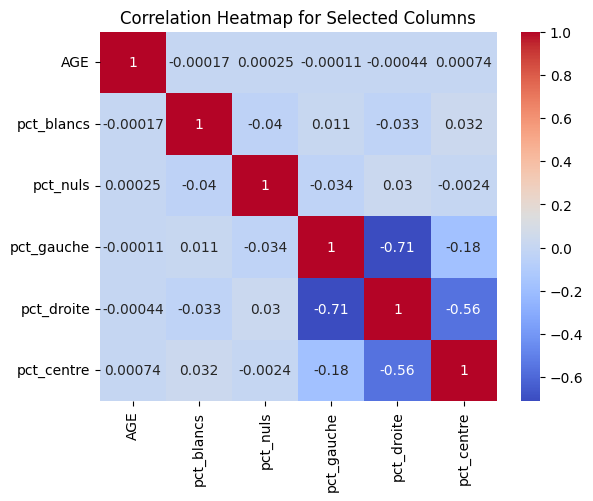

Correlation between pct_* variables and AGE categories:
             AGE_0.0   AGE_2.0   AGE_3.0   AGE_4.0   AGE_5.0   AGE_6.0
pct_blancs -0.000175  0.000511  0.000557  0.000290  0.000191 -0.000694
pct_nuls   -0.000031  0.000131  0.000347  0.000044  0.000227  0.000252
pct_gauche  0.000462 -0.000011  0.000109  0.000180  0.000273  0.000065
pct_droite -0.000579  0.000135 -0.000247 -0.000226 -0.000562 -0.000938
pct_centre  0.000266 -0.000176  0.000218  0.000106  0.000464  0.001237


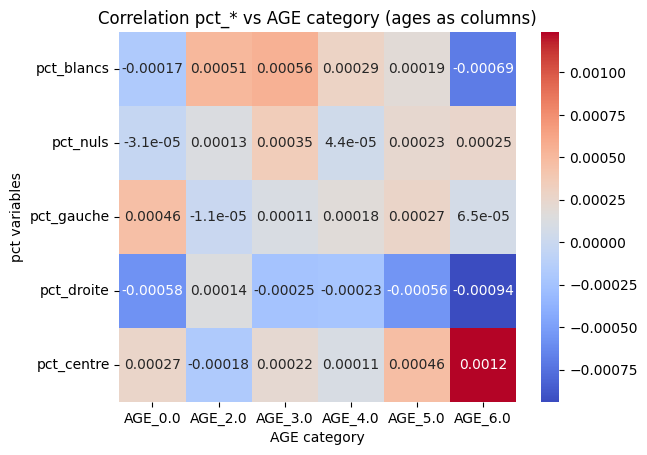

Correlation between pct_* variables and CIVIL_STATUS categories:
            _Célibataire  _Divorcé  _En concubinage, union libre    _Marié  \
pct_blancs      0.000292 -0.000414                     -0.000132  0.000406   
pct_nuls        0.000111  0.000159                      0.000151  0.000166   
pct_gauche     -0.000098  0.000934                      0.000058 -0.000110   
pct_droite     -0.000132 -0.000645                     -0.000052 -0.000155   
pct_centre      0.000300 -0.000195                      0.000005  0.000347   

              _Pacsé    _Total     _Veuf  
pct_blancs -0.001042  0.000349  0.000114  
pct_nuls   -0.001024  0.000097  0.000215  
pct_gauche  0.000577 -0.000529 -0.000201  
pct_droite -0.000151  0.000531 -0.000021  
pct_centre -0.000466 -0.000122  0.000267  


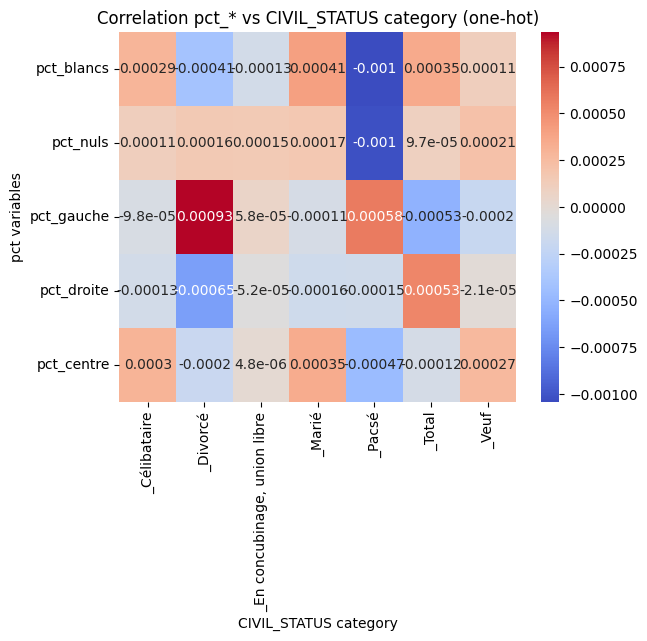

Correlation between pct_* variables and COUPLE categories:
            COUPLE_Non  COUPLE_Oui  COUPLE_Total
pct_blancs   -0.000189   -0.000463      0.000554
pct_nuls      0.000079   -0.000396      0.000268
pct_gauche    0.000626   -0.000569     -0.000053
pct_droite   -0.000299    0.000943     -0.000544
pct_centre   -0.000318   -0.000649      0.000823


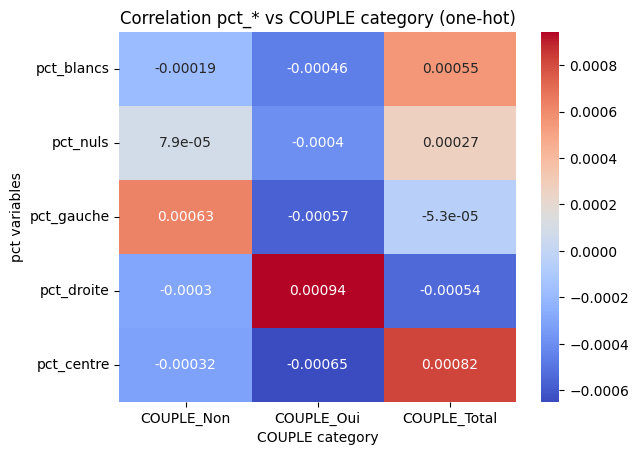

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt
age_cols = [col for col in df_fuse.columns if 'age' in col.lower()]
pct_cols = ['pct_blancs', 'pct_nuls', 'pct_gauche', 'pct_droite', 'pct_centre']
selected_cols = age_cols + pct_cols

corr_selected = df_fuse[selected_cols].corr()

sns.heatmap(corr_selected, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap for Selected Columns')
plt.show()

def corr_and_heatmap(one_hot, title_base):
    corr_df = pd.concat([df_fuse[pct_cols], one_hot], axis=1).corr()
    corr_part = corr_df.loc[pct_cols, one_hot.columns]
    print(f"Correlation between pct_* variables and {title_base} categories:")
    print(corr_part)
    sns.heatmap(corr_part, annot=True, cmap='coolwarm')
    plt.title(f'Correlation pct_* vs {title_base} category (one-hot)')
    plt.xlabel(f'{title_base} category')
    plt.ylabel('pct variables')
    plt.show()

age_dummies = pd.get_dummies(df_fuse['AGE'], prefix='AGE')
corr_age_pct = pd.concat([df_fuse[pct_cols], age_dummies], axis=1).corr().loc[pct_cols, age_dummies.columns]
print("Correlation between pct_* variables and AGE categories:")
print(corr_age_pct)
sns.heatmap(corr_age_pct, annot=True, cmap='coolwarm')
plt.title('Correlation pct_* vs AGE category (ages as columns)')
plt.xlabel('AGE category')
plt.ylabel('pct variables')
plt.show()

civil_dummies = pd.get_dummies(df_fuse['CIVIL_STATUS'], prefix='')
corr_and_heatmap(civil_dummies, 'CIVIL_STATUS')

couple_dummies = pd.get_dummies(df_fuse['COUPLE'], prefix='COUPLE')
corr_and_heatmap(couple_dummies, 'COUPLE')